# Comparison of deep learning models for arrhythmia detection

## Initialisation

In [ ]:
# Imports
import os
from os.path import join as osj
import pandas as pd
import numpy as np
import torch
import wfdb
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Directory where the dataset is stored
dataset_directory = 'mit-bih-arrhythmia-database-1.0.0/'

# Get an array of all ids
record_ids = pd.read_csv('mit-bih-arrhythmia-database-1.0.0/RECORDS', header=None).to_numpy().reshape(-1)

# Initialise dictionaries to store data
lead1 = {}
lead2 = {}
annotations = {}

# Load ECG signals and annotations
for id in record_ids:
    signals, info = wfdb.io.rdsamp(osj(dataset_directory, str(id)))
    annotation = wfdb.rdann(dataset_directory + str(id), "atr")
    lead1[id] = signals[:, 0]
    lead2[id] = signals[:, 1]
    annotations[id] = annotation
            

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N',

Text(0, 0.5, 'Amplitude (mV)')

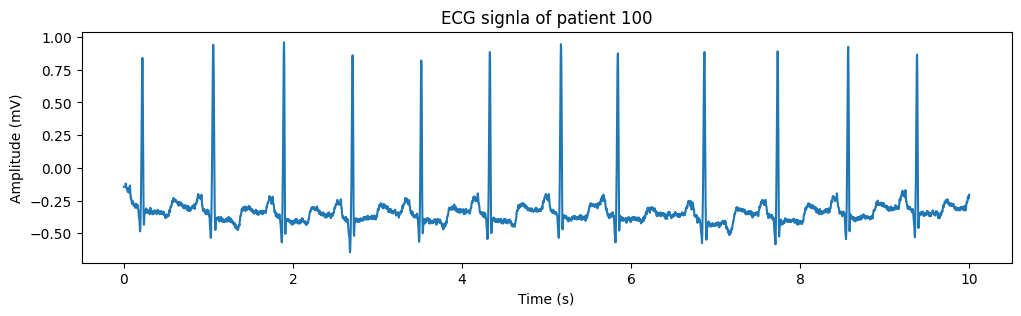

In [20]:
patient_id = 100 # can change
starting_time = 0 # can change
ending_time = 10 # can change

starting_signal_point = starting_time*350
ending_signal_point = ending_time*350 # As sampling frequency is 350 Hz
x = np.arange(starting_time, ending_time, 1/350)
signal = lead1[patient_id][starting_signal_point: ending_signal_point]

plt.figure(figsize=(12, 3), dpi=100)
plt.plot(x, signal)
plt.title(f'ECG signla of patient {patient_id}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')

In [18]:
print(ecg_annotations)

{'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V1'], 'comments': ['56 F 1971 3655 x2', 'None', 'The PVCs are uniform.']}


## Data Preprocessing

### Filtering 

### Segmentation

### Normalisation

## Models

### MLP with feature extract layer

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        
        # Feature extraction layer
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### CNN

In [ ]:
class CNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CNN, self).__init__()
        
        # Feature extraction layers
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128 * (input_size // 4), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

### LSTM

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.dropout(x)
        x = self.fc(x)
        return x

### Hybrid

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(CNN_LSTM, self).__init__()
        
        # Feature extraction layers (CNN)
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # LSTM for sequence modeling
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        
        # Fully connected layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.permute(0, 2, 1)  # Reshape for LSTM (batch, seq_len, features)
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time step output
        x = self.classifier(x)
        return x


### Transformer

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, num_classes, num_heads=4, num_layers=2, dim_feedforward=128):
        super(TransformerModel, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=num_heads, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv1(x)
        x = x.permute(2, 0, 1)  # Reshape for Transformer (seq_len, batch, features)
        x = self.transformer_encoder(x)
        x = x.mean(dim=0)  # Global Average Pooling
        x = self.dropout(x)
        x = self.fc(x)
        return x

## Training

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return total_loss / len(dataloader), correct / len(dataloader.dataset)

## Testing

In [ ]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    return correct / len(dataloader.dataset)

## Evaluation